# Introduction to Potentials

galpy provides a large library of gravitational potentials. This notebook covers how to
initialize potentials, evaluate them, combine them, and compute useful dynamical quantities.

See also: [Potential Wrappers](wrappers.ipynb) for time-dependent and rotating potentials,
[SCF and Multipole Expansions](scf_and_multipole.ipynb) for basis-function representations,
[Dissipative Forces](dissipative.ipynb) for working with dissipative forces such as dynamical friction, 
[Milky Way Potentials](milky_way_potentials.ipynb) for pre-built MW models, [N-body snapshots](nbody_snapshots.ipynb) for working with N-body simulation data, and [Other codes](other_codes.ipynb) for info on how to use galpy potentials with a host of other codes.

In [1]:
%matplotlib inline
import numpy
from matplotlib import pyplot as plt
from galpy import potential
from galpy.potential import (
    MiyamotoNagaiPotential,
    NFWPotential,
    HernquistPotential,
    LogarithmicHaloPotential,
    MWPotential2014,
)
from galpy.util import conversion
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Initializing a potential

Let's start by creating a Miyamoto-Nagai disk potential. In galpy's natural units,
velocities are normalized to the circular velocity at the Sun, and distances to the
Sun's Galactocentric radius.

In [2]:
mp = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=1.0)
mp

MiyamotoNagaiPotential with internal parameters: amp=1.4632953564490085, a=0.5, b=0.0375 and physical outputs off

## Evaluating potential values and forces

Evaluate the potential at (R, z) = (1, 0), i.e., the solar position in natural units. Calling the potential object directly returns the potential value:

In [3]:
# Potential value at (R, z) = (1, 0)
print("Phi(R=1, z=0) =", mp(1.0, 0.0))

Phi(R=1, z=0) = -1.2889062500000001


<div class="alert alert-warning">

**Warning**

galpy potentials do *not* necessarily approach zero at infinity. To compute, for example, the escape velocity or whether or not an orbit is unbound, you need to take into account the value of the potential at infinity: $v_{\mathrm{esc}}(r) = \sqrt{2[\Phi(\infty)-\Phi(r)]}$. If you want to create a potential that does go to zero at infinity, you can add a `NullPotential` with value equal to minus the original potential evaluated at infinity.

</div>

<div class="alert alert-info">

**Tip**

Potentials can be initialized and evaluated with arguments specified as astropy Quantities with units. Use the configuration parameter `astropy-units = True` to get output values as a Quantity. See the section on [initializing potentials with physical parameters](#Initializing-potentials-with-physical-parameters) below.

</div>

To evaluate the forces, use the `Rforce` and `zforce` methods:

In [4]:
# Radial and vertical forces
print("F_R(R=1, z=0) =", mp.Rforce(1.0, 0.0))
print("F_z(R=1, z=0.1) =", mp.zforce(1.0, 0.1))

F_R(R=1, z=0) = -1.0
F_z(R=1, z=0.1) = -0.5194918992748312


The azimuthal torque can be computed with the `phitorque` method:

In [5]:
print("N_phi(R=1, z=0) =", mp.phitorque(1.0, 0.0))

N_phi(R=1, z=0) = 0.0


## The functional interface

galpy also provides module-level functions that work on single potentials or lists of potentials:

In [6]:
print("evaluatePotentials:", potential.evaluatePotentials(mp, 1.0, 0.0))
print("evaluateRforces:", potential.evaluateRforces(mp, 1.0, 0.0))
print("evaluatezforces:", potential.evaluatezforces(mp, 1.0, 0.1))
print("evaluatephitorques:", potential.evaluatephitorques(mp, 1.0, 0.0))

evaluatePotentials: -1.2889062500000001
evaluateRforces: -1.0
evaluatezforces: -0.5194918992748312
evaluatephitorques: 0.0


## Combining potentials

Potentials can be combined using the `+` operator. `MWPotential2014` is a built-in
composite potential with three components:

In [7]:
print(MWPotential2014)

CompositePotential of 3 potentials:
	PowerSphericalPotentialwCutoff with internal parameters: amp=0.029994597188218296, alpha=1.8, rc=0.2375
	MiyamotoNagaiPotential with internal parameters: amp=0.7574802019371595, a=0.375, b=0.035
	NFWPotential with internal parameters: amp=4.852230533527998, a=2.0
and physical outputs off


You can also combine potentials yourself using the `+` operator:

In [8]:
# You can also combine potentials yourself
my_pot = MiyamotoNagaiPotential(a=0.5, b=0.0375, normalize=0.6) + NFWPotential(
    a=4.5, normalize=0.35
)
print("Phi(1,0) =", my_pot(1.0, 0.0))

Phi(1,0) = -4.498828040219292


<div class="alert alert-info">

**Tip**

To simply adjust the amplitude of a Potential instance, you can multiply the
instance by a number or divide it by a number. For example,
`pot = 2. * LogarithmicHaloPotential(amp=1.)` is equivalent to
`pot = LogarithmicHaloPotential(amp=2.)`. This is useful if you want to quickly
adjust the mass of a potential.

</div>

## Physical units

The easiest way to work with physical units in galpy is to initialize potentials with
the `ro=` and `vo=` parameters. When these are set, output is automatically returned
in physical units. You can toggle this behavior with `use_physical=True/False` or
with the `turn_physical_on()` and `turn_physical_off()` methods.

In [9]:
# Initialize MWPotential2014 with physical scales
ro, vo = 8.0, 220.0  # kpc, km/s
MWPotential2014.turn_physical_on(ro=ro, vo=vo)

# Now output is automatically in physical units
print("v_circ(R=8 kpc):", MWPotential2014.vcirc(1.0), "km/s")
print("F_R(R=8 kpc):", potential.evaluateRforces(MWPotential2014, 1.0, 0.0), "km/s/Myr")

# Toggle physical output off temporarily with use_physical=False
print(
    "\nF_R (natural units):",
    potential.evaluateRforces(MWPotential2014, 1.0, 0.0, use_physical=False),
)

# Or turn it off entirely
MWPotential2014.turn_physical_off()
print(
    "F_R after turn_physical_off:", potential.evaluateRforces(MWPotential2014, 1.0, 0.0)
)

v_circ(R=8 kpc): 220.0 km/s
F_R(R=8 kpc): -6.187408598526455 km/s/Myr

F_R (natural units): -1.0
F_R after turn_physical_off: -1.0


Alternatively, you can use the `galpy.util.conversion` module to manually convert
from natural units to physical units. This is useful when you want to keep potentials
in natural units but occasionally need a physical value:

In [10]:
# Manual conversion using galpy.util.conversion
F_R_nat = potential.evaluateRforces(MWPotential2014, 1.0, 0.0)
F_R_phys = F_R_nat * conversion.force_in_kmsMyr(vo, ro)
print(
    f"F_R at solar position: {F_R_nat:.4f} (natural), {F_R_phys:.4f} km/s/Myr (physical)"
)

F_R at solar position: -1.0000 (natural), -6.1874 km/s/Myr (physical)


## Densities

You can evaluate the density directly or via the Poisson equation:

In [11]:
# Direct density evaluation
print("Density (direct):", mp.dens(1.0, 0.0))
# Via the Poisson equation
print("Density (Poisson):", mp.dens(1.0, 0.0, forcepoisson=True))

Density (direct): 1.1145444383277576
Density (Poisson): 1.1145444383277574


The functional interface also works for densities of combinations of potentials, and so does
the method version:

In [12]:
print(
    "MWPotential2014 density at (1,0):",
    potential.evaluateDensities(MWPotential2014, 1.0, 0.0),
)

MWPotential2014 density at (1,0): 0.5750860312226487


In [13]:
MWPotential2014.dens(1.0, 0.0, ro=8.0, vo=220.0, use_physical=True, quantity=True)

<Quantity 0.10112001 solMass / pc3>

## DoubleExponentialDiskPotential density

Another example: an exponential disk potential, where we can compare the
analytical density to that computed via the Poisson equation and we plot the density.

Relative difference: 1.5308327107952697e-14


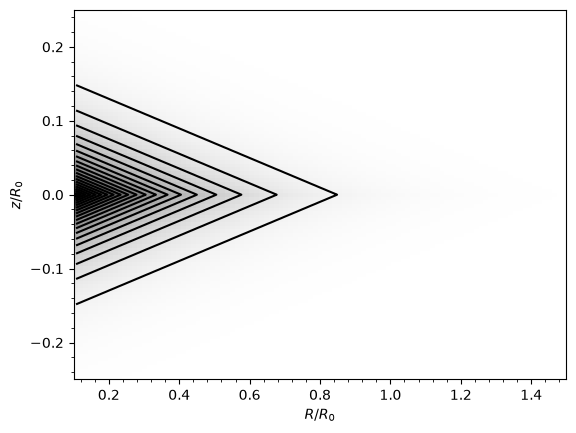

In [14]:
from galpy.potential import DoubleExponentialDiskPotential

dp = DoubleExponentialDiskPotential(hr=1.0 / 4.0, hz=1.0 / 20.0, normalize=1.0)
# The Poisson-equation density requires numerical integration, so the agreement
# is slightly less good than for Miyamoto-Nagai, but still better than a percent:
print(
    "Relative difference:",
    (dp.dens(1.0, 0.0, forcepoisson=True) - dp.dens(1.0, 0.0)) / dp.dens(1.0, 0.0),
)
dp.plotDensity(rmin=0.1, zmax=0.25, zmin=-0.25, nrs=101, nzs=101);

## Flattening

We can evaluate the flattening of the potential as $\sqrt{|z\,F_R / R\,F_Z|}$:

In [15]:
print("Flattening of Miyamoto-Nagai at (1, 0.125):", mp.flattening(1.0, 0.125))
print(
    "Flattening of MWPotential2014 at (1, 0.125):",
    MWPotential2014.flattening(1.0, 0.125),
)

Flattening of Miyamoto-Nagai at (1, 0.125): 0.4549542914935209
Flattening of MWPotential2014 at (1, 0.125): 0.6123167530565863


## Plotting potentials

galpy potentials have built-in plotting methods:

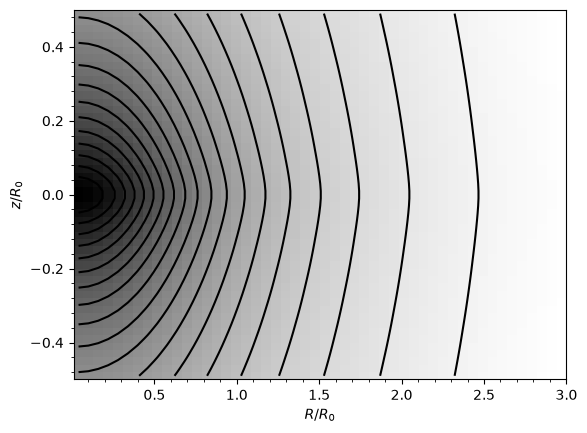

In [16]:
# Plot the potential in the (R, z) plane
mp.plot(rmin=0.01, rmax=3.0, zmin=-0.5, zmax=0.5, nrs=50, nzs=50);

We can also plot the density of a composite potential like `MWPotential2014`:

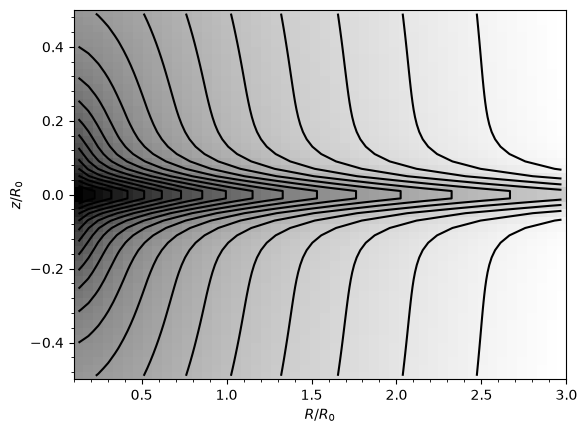

In [17]:
# Plot the density
potential.plotDensities(
    MWPotential2014, rmin=0.1, rmax=3.0, zmin=-0.5, zmax=0.5, nrs=50, nzs=50, log=True
);

For non-axisymmetric potentials, we can plot the density in the x-y plane using `xy=True`:

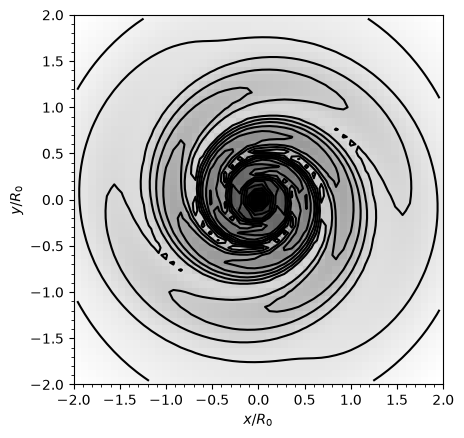

In [18]:
from galpy.potential import SpiralArmsPotential

sp = SpiralArmsPotential(amp=0.6)
lp = LogarithmicHaloPotential(normalize=1.0)
potential.plotDensities(
    sp + lp, rmin=-2.0, rmax=2.0, zmin=-2.0, zmax=2.0, nrs=50, nzs=50, log=True, xy=True
)
plt.gca().set_aspect("equal");

## Circular-orbit quantities

galpy can compute the circular velocity, epicycle frequency, vertical frequency,
and angular frequency:

In [19]:
print("v_circ(R=1):", MWPotential2014.vcirc(1.0))
print("Omega_c(R=1):", MWPotential2014.omegac(1.0))
print("Epicycle freq(R=1):", MWPotential2014.epifreq(1.0))
print("Vertical freq(R=1):", MWPotential2014.verticalfreq(1.0))

v_circ(R=1): 1.0
Omega_c(R=1): 1.0
Epicycle freq(R=1): 1.340959647011537
Vertical freq(R=1): 2.7255405754769875


Let's plot the rotation curve of `MWPotential2014`:

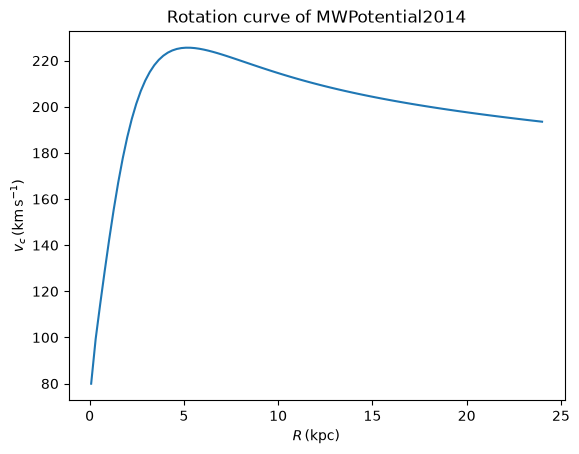

In [20]:
# Plot the rotation curve
Rs = numpy.linspace(0.01, 3.0, 101)
plt.plot(Rs * 8, [MWPotential2014.vcirc(R, ro=8.0, vo=220.0) for R in Rs])
plt.xlabel(r"$R\,(\mathrm{kpc})$")
plt.ylabel(r"$v_c\,(\mathrm{km\,s}^{-1})$")
plt.title("Rotation curve of MWPotential2014");

## Spiral density wave diagram: $\Omega - n\kappa/m$

As an application of the above, we can compute the diagram of $\Omega - n\kappa/m$, which is important for understanding kinematic
spiral density waves. It shows the locations of various resonances.

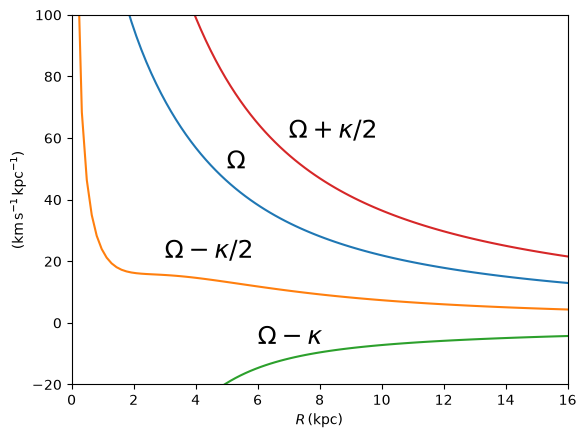

In [21]:
def OmegaMinusKappa(pot, Rs, n, m, ro=8.0, vo=220.0):
    return pot.omegac(Rs / ro, ro=ro, vo=vo) - n / m * pot.epifreq(
        Rs / ro, ro=ro, vo=vo
    )


Rs = numpy.linspace(0.01, 16.0, 101)
plt.plot(Rs, OmegaMinusKappa(MWPotential2014, Rs, 0, 1))
plt.plot(Rs, OmegaMinusKappa(MWPotential2014, Rs, 1, 2))
plt.plot(Rs, OmegaMinusKappa(MWPotential2014, Rs, 1, 1))
plt.plot(Rs, OmegaMinusKappa(MWPotential2014, Rs, 1, -2))
plt.xlim(0.0, 16.0)
plt.ylim(-20.0, 100.0)
plt.xlabel(r"$R\,(\mathrm{kpc})$")
plt.ylabel(r"$(\mathrm{km\,s}^{-1}\,\mathrm{kpc}^{-1})$")
plt.text(3.0, 21.0, r"$\Omega-\kappa/2$", size=18.0)
plt.text(5.0, 50.0, r"$\Omega$", size=18.0)
plt.text(7.0, 60.0, r"$\Omega+\kappa/2$", size=18.0)
plt.text(6.0, -7.0, r"$\Omega-\kappa$", size=18.0);

## Lindblad resonances

Find the radius of the inner and outer Lindblad resonances for a given pattern speed:

In [22]:
# Lindblad resonances for a pattern speed similar to the Milky Way's bar
# Using the Miyamoto-Nagai potential for this example:
print("Corotation:", mp.lindbladR(5.0 / 3.0, m="corotation"))
print("Inner Lindblad resonance (m=2):", mp.lindbladR(5.0 / 3.0, m=2))
print("Outer Lindblad resonance (m=-2):", mp.lindbladR(5.0 / 3.0, m=-2))

Corotation: 0.6027911166042229
Inner Lindblad resonance (m=2): None
Outer Lindblad resonance (m=-2): 0.9906190683480501


The `None` for `m=2` means there is no inner Lindblad resonance for this potential.

## Interpolated potentials

For expensive potentials, galpy provides `interpRZPotential` (for axisymmetric potentials)
and `interpSphericalPotential` (for spherical potentials) that pre-compute a grid and
interpolate. `interpSphericalPotential` can be initialized from a function giving the
radial force or from an existing spherical potential. See the
[API documentation](../../reference/potentialinterprz.rst) for full details.

In [23]:
from galpy.potential import interpRZPotential

# Create an interpolated version of MWPotential2014
ip = interpRZPotential(
    RZPot=MWPotential2014,
    rgrid=(0.01, 3.0, 51),
    zgrid=(0.0, 0.5, 26),
    interpPot=True,
    interpRforce=True,
    interpzforce=True,
)
# Compare
print("Original:", potential.evaluatePotentials(MWPotential2014, 1.0, 0.1))
print("Interpolated:", ip(1.0, 0.1))

Original: -1.3531320418152721
Interpolated: -1.3531320418152721


These interpolated potentials can be used anywhere a regular potential can be used, and they are much faster to evaluate than the original potential. They are especially useful for orbit integration, where the potential is evaluated many times.

## Initializing potentials with physical parameters

You can initialize potentials directly with physical parameters (e.g., `amp` in
$M_\odot$, `a` in kpc) by passing `ro=` and `vo=`. When initialized this way,
physical output is turned on automatically. Use `use_physical=False` to get output
in natural units when needed.

In [24]:
from astropy import units as u

# NFW halo with physical parameters -- physical output is on by default
nfw = NFWPotential(mvir=1.0, conc=15.0, ro=8.0, vo=220.0)

# Output is in physical units (km^2/s^2) automatically
print("Phi(R=1, z=0) [physical]:", nfw(1.0, 0.0), "km^2/s^2")

# Use use_physical=False to get natural units
print("Phi(R=1, z=0) [natural]:", nfw(1.0, 0.0, use_physical=False))

# You can also pass astropy Quantities directly
print("Phi(8 kpc, 0 kpc):", nfw(8.0 * u.kpc, 0.0 * u.kpc), "km^2/s^2")

Phi(R=1, z=0) [physical]: -96354.67477240822 km^2/s^2
Phi(R=1, z=0) [natural]: -1.9907990655456245
Phi(8 kpc, 0 kpc): -96354.67477240822 km^2/s^2


This also works for other potential types, such as `MiyamotoNagaiPotential`:

In [25]:
# Miyamoto-Nagai with physical amplitude (amp in Msun, a and b in kpc)
mn_phys = MiyamotoNagaiPotential(
    amp=5e10 * u.Msun, a=3.0 * u.kpc, b=0.28 * u.kpc, ro=8.0, vo=220.0
)
print("v_circ(R=1) [physical]:", mn_phys.vcirc(1.0), "km/s")
print("v_circ(R=1) [natural]:", mn_phys.vcirc(1.0, use_physical=False))

# turn_physical_off / turn_physical_on lets you switch the default
mn_phys.turn_physical_off()
print("\nAfter turn_physical_off:")
print("v_circ(R=1):", mn_phys.vcirc(1.0))

mn_phys.turn_physical_on(ro=8.0, vo=220.0)
print("\nAfter turn_physical_on:")
print("v_circ(R=1):", mn_phys.vcirc(1.0), "km/s")

v_circ(R=1) [physical]: 145.9185599862874 km/s
v_circ(R=1) [natural]: 0.6632661817558517

After turn_physical_off:
v_circ(R=1): 0.6632661817558517

After turn_physical_on:
v_circ(R=1): 145.9185599862874 km/s


<div class="alert alert-info">

**Tip**

The `amp=` parameter has different units for different potentials. Check each potential's documentation to learn what the units are. For example, for a `LogarithmicHaloPotential` the units are velocity squared, while for a `MiyamotoNagaiPotential` they are units of mass. Check each potential's API documentation for the units of `amp=`.

</div>

<div class="alert alert-warning">

**Warning**

When combining potentials with different `ro=` and `vo=` values, unexpected behavior can result. It is best to use the same `ro=` and `vo=` for all potentials in a combination.

</div>